In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import torch

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


In [2]:
df_synthea = pd.read_csv(project_root / "data" / "multidimensional_synthea_10k.csv")
df_synthea['time'] = df_synthea['time'].clip(upper=40)

# Dictionnaire pour simplifier les noms des médicaments
medication_mapping = {
    'NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler': 'Albuterol Inhaler',
    '120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler': 'Fluticasone Inhaler',
    'insulin human  isophane 70 UNT/ML / Regular Insulin  Human 30 UNT/ML Injectable Suspension [Humulin]': 'Insulin',
    '24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet': 'Metformin',
    'Hydrochlorothiazide 25 MG Oral Tablet': 'HCTZ 25mg',
    'amLODIPine 5 MG / Hydrochlorothiazide 12.5 MG / Olmesartan medoxomil 20 MG Oral Tablet': 'Amlodipine Combo',
    'Atenolol 50 MG / Chlorthalidone 25 MG Oral Tablet': 'Atenolol Combo',
    'Hydrochlorothiazide 12.5 MG': 'HCTZ 12.5mg',
    'Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray': 'Nitroglycerin Spray',
    'Simvastatin 10 MG Oral Tablet': 'Simvastatin 10mg'
}

df_synthea['medication_events'] = df_synthea['medication_events'].map(medication_mapping)

print(f"Nombre de patients : {df_synthea['patient_id'].nunique()}")
print(f"Temps de suivi max (jours) : {df_synthea['time'].max()}")
df_synthea.head()

Nombre de patients : 901
Temps de suivi max (jours) : 40


,patient_id,time,medication_events
0,1,11,Fluticasone Inhaler
1,1,11,Albuterol Inhaler
2,1,22,Fluticasone Inhaler
3,1,22,Albuterol Inhaler
4,1,35,Fluticasone Inhaler


In [3]:
# Fréquence des médicaments :
df_synthea.groupby('medication_events')['patient_id'].nunique().sort_values(ascending=False)

medication_events
Albuterol Inhaler      602
Fluticasone Inhaler    586
Metformin              175
Insulin                138
HCTZ 25mg               88
Atenolol Combo          69
Nitroglycerin Spray     69
Amlodipine Combo        63
Simvastatin 10mg        54
HCTZ 12.5mg             39
Name: patient_id, dtype: int64

In [4]:
label_encoder = LabelEncoder()
timed_event_structure = df_synthea.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['medication_events'])
timed_event_structure.drop(columns=['medication_events'], inplace=True)

timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_

tca = TCA(data=timed_event_structure,
          index_col='ID_PATIENT',
          time_col='Time', 
          event_col='Event',
          mode='multidimensional'
         )

tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (30753, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3
4      4              4
5      5              5
6      6              6
7      7              7
8      8              8
9      9              9
Tensor shape: torch.Size([901, 10, 41])


Patient utilisé pour la visualisation: 21


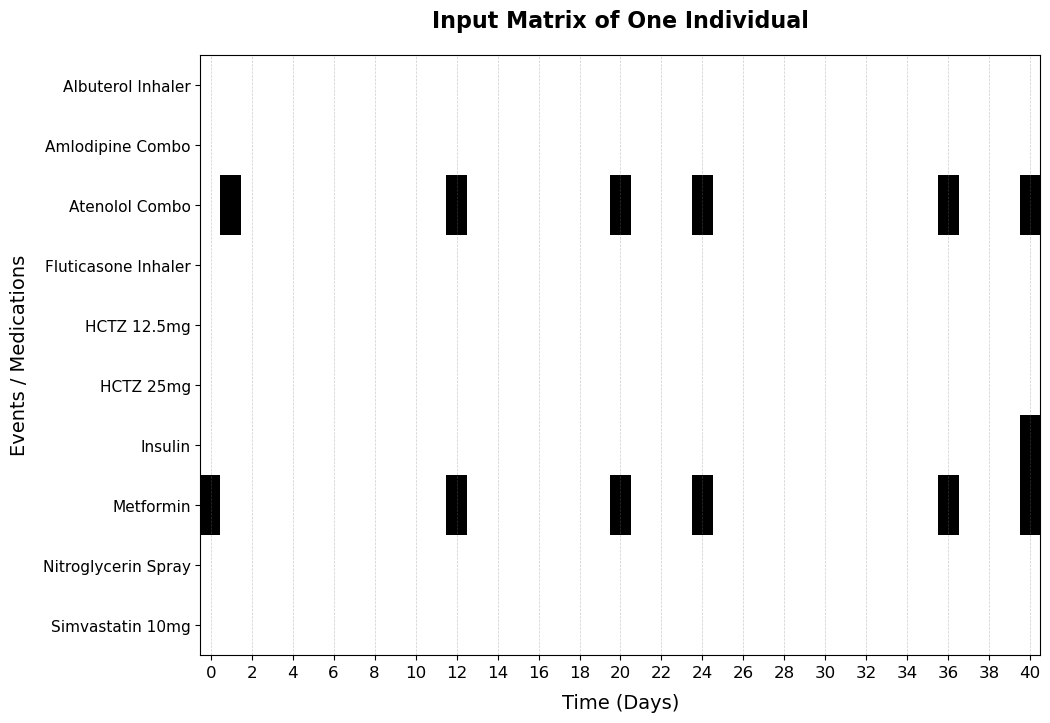

In [5]:
# Un patient avec au moins 3/4 traitements diff.
patients_complexes = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: len(set(group['Event'])) >= 3
)['ID_PATIENT'].unique()

patient_index = int(patients_complexes[0])
print(f"Patient utilisé pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events, time_unit="Days")

In [6]:
# Hyperparametres de la demo
reg_term_ns = 0.5
reg_term_s = 0.1
metric = 'Bernoulli'
learning_rate = 1e-2
n_epochs = 200  # 30 pour demo rapide, 100+ pour entrainement plus stable
rank = 2
time_window_length = 12

In [8]:
tca.analyzer.fit_swotted_decomposition(
            tensor, rank=rank, time_window_length=time_window_length,
            reg_term_ns=reg_term_ns, reg_term_s=reg_term_s,
            metric=metric, learning_rate=learning_rate, n_epochs=n_epochs
        )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 240    | n/a   | n/a  
---------------------------------------------------------------
240       Trainable params
0         Non-trainable params
240       Total params
0.001     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 - train_loss: 144.777649
Epoch 2/200 - train_loss: 77.255829
Epoch 3/200 - train_loss: 72.471695
Epoch 4/200 - train_loss: 68.868843
Epoch 5/200 - train_loss: 72.917114
Epoch 6/200 - train_loss: 60.998699
Epoch 7/200 - train_loss: 64.586754
Epoch 8/200 - train_loss: 56.294197
Epoch 9/200 - train_loss: 57.453793
Epoch 10/200 - train_loss: 59.960693
Epoch 11/200 - train_loss: 77.053947
Epoch 12/200 - train_loss: 60.385845
Epoch 13/200 - train_loss: 59.516926
Epoch 14/200 - train_loss: 61.703182
Epoch 15/200 - train_loss: 58.221203
Epoch 16/200 - train_loss: 61.761440
Epoch 17/200 - train_loss: 59.708157
Epoch 18/200 - train_loss: 59.688221
Epoch 19/200 - train_loss: 57.788200
Epoch 20/200 - train_loss: 56.251568
Epoch 21/200 - train_loss: 57.011593
Epoch 22/200 - train_loss: 59.205650
Epoch 23/200 - train_loss: 58.311489
Epoch 24/200 - train_loss: 65.599304
Epoch 25/200 - train_loss: 61.004013
Epoch 26/200 - train_loss: 57.437080
Epoch 27/200 - train_loss: 54.399632
Epoch 28/

`Trainer.fit` stopped: `max_epochs=200` reached.


Decomposed into 901 pathways with rank 2 and time window length 12
Success rate for the entire dataset: -3.3865


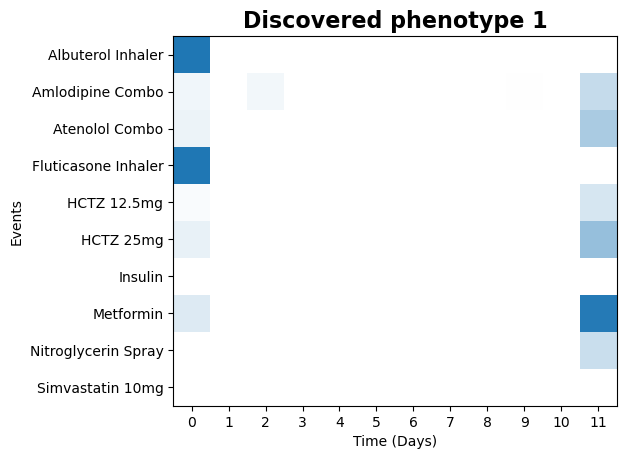

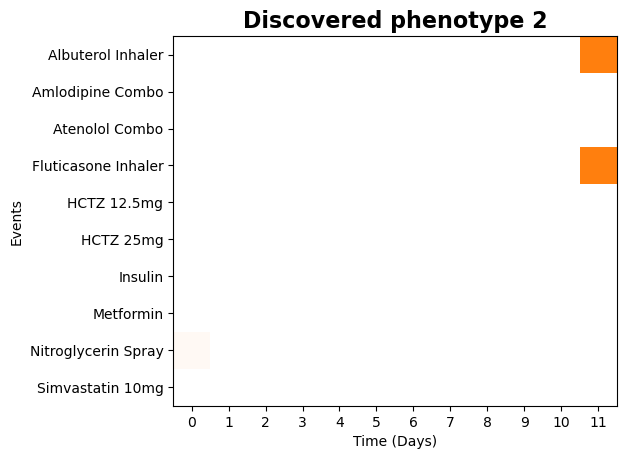

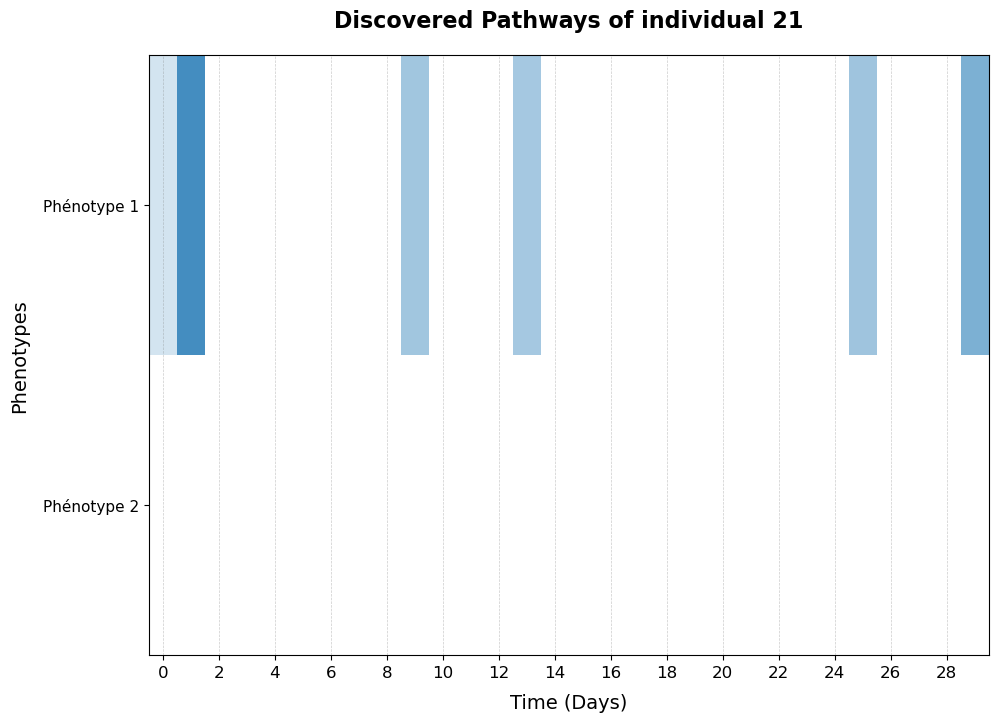

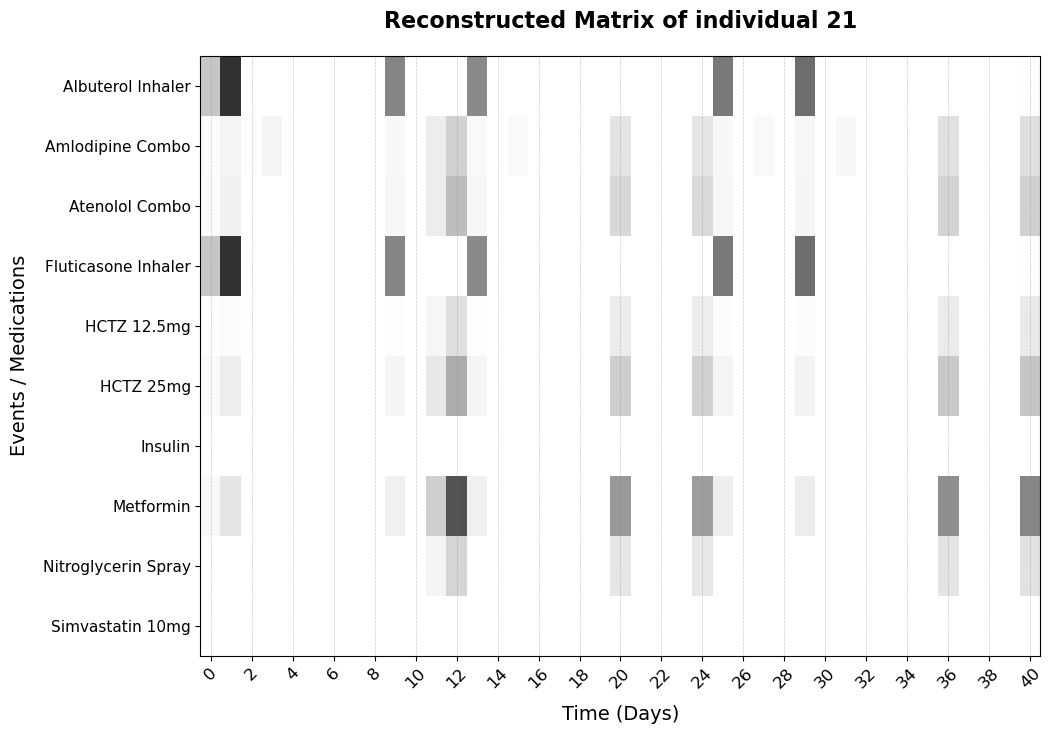

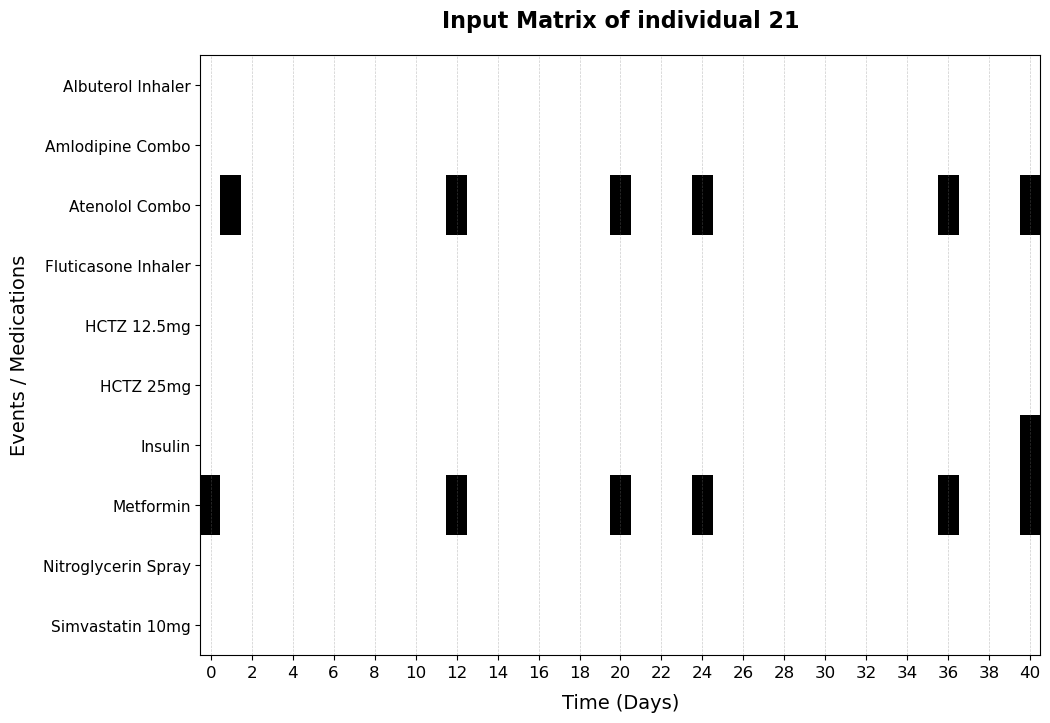

In [9]:
tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index, time_unit='Days')

In [94]:
from sklearn.preprocessing import MinMaxScaler
ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (901, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.580865,0.468483,0.262669,1
1,0.381165,0.471651,0.427227,2
2,0.356226,0.625251,0.290223,3
3,0.544724,0.468935,0.729881,4
4,0.391923,0.552701,0.393651,5


INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.00 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


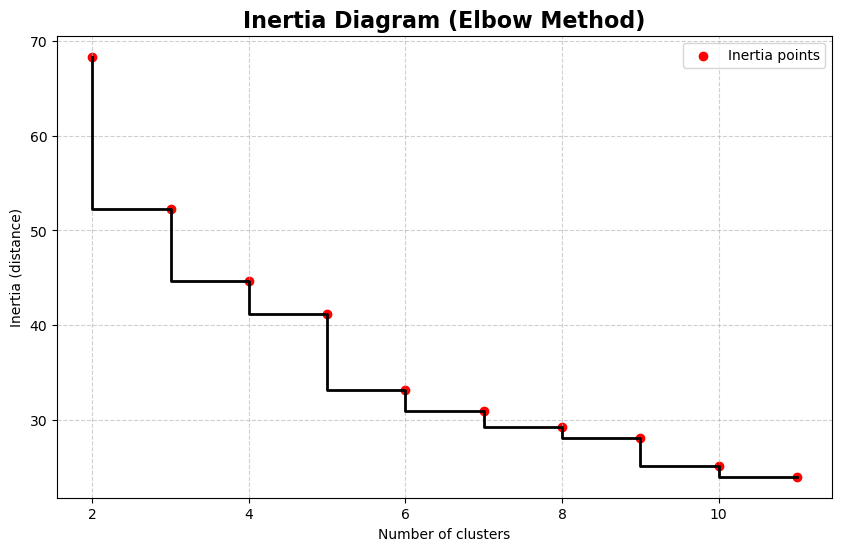

In [95]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)
tca.plot_inertia(linkage_matrix)

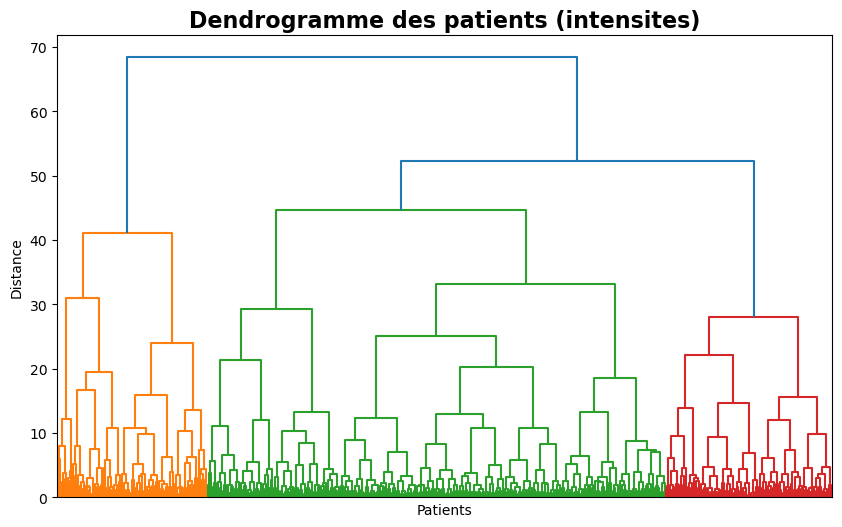

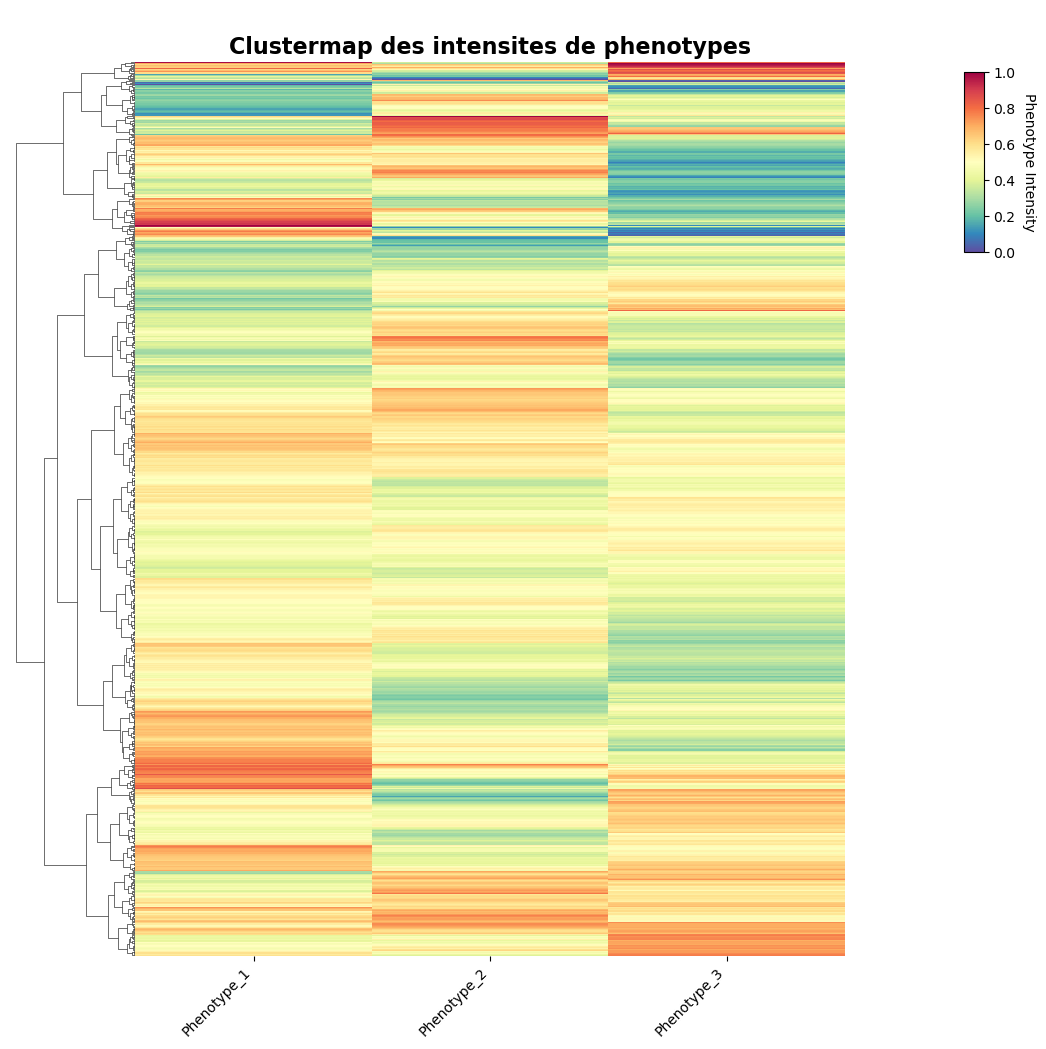

Effectifs par cluster:
1    175
2    154
3    379
4    193
Name: count, dtype: int64


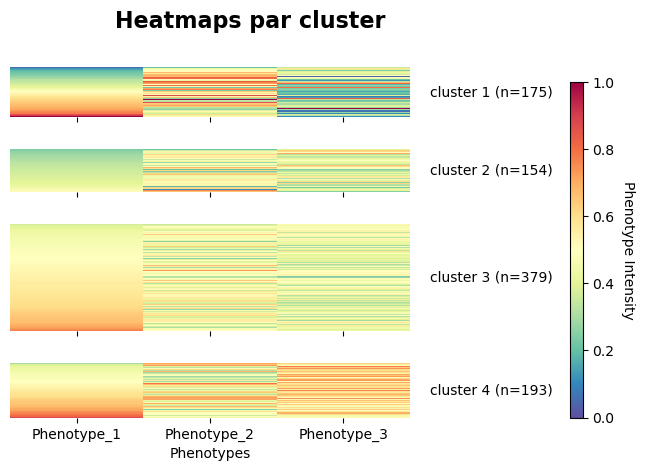

In [96]:
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')

In [97]:
nb_meds = timed_event_structure.groupby('ID_PATIENT')['Event'].nunique()
for c in sorted(set(clusters)):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    print(f"Cluster {c} — nb médicaments moyen : {nb_meds[ids].mean():.2f}")

Cluster 1 — nb médicaments moyen : 2.12
Cluster 2 — nb médicaments moyen : 2.06
Cluster 3 — nb médicaments moyen : 2.09
Cluster 4 — nb médicaments moyen : 2.08


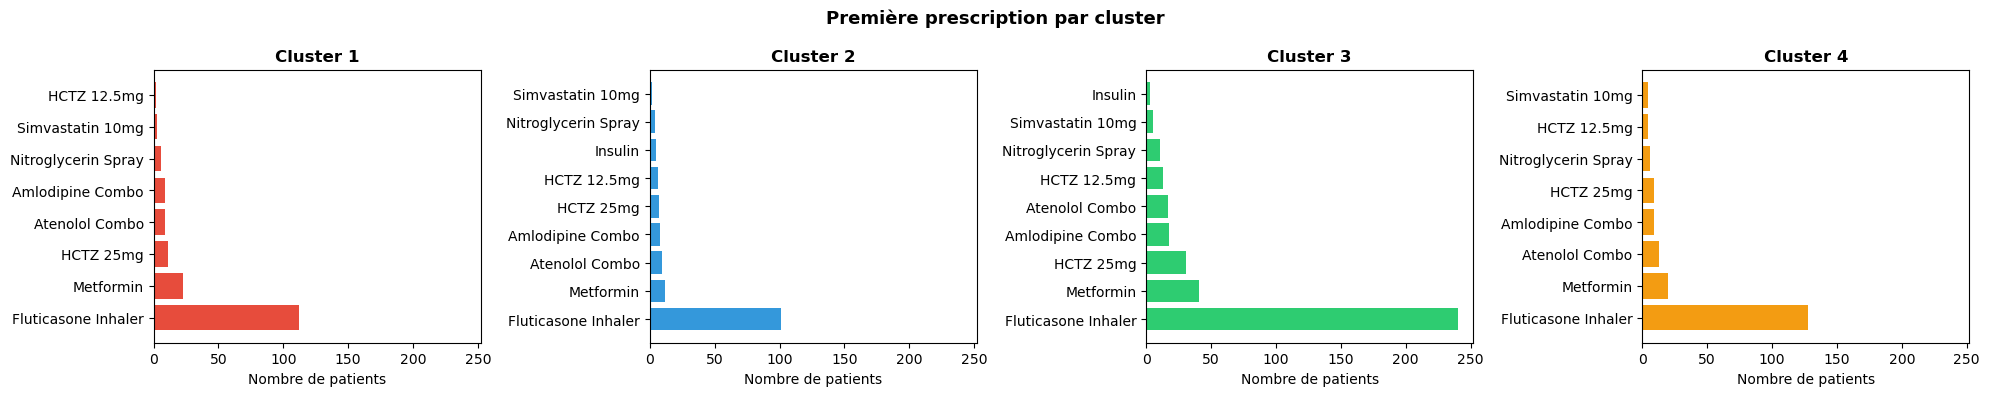

In [101]:
first_med = timed_event_structure.groupby('ID_PATIENT').apply(
    lambda x: x.loc[x['Time'].idxmin(), 'Event']
).map(dict(enumerate(noms_events)))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, len(set(clusters)), figsize=(5 * len(set(clusters)), 4), squeeze=False, sharex=True)

for ax, c in zip(axes[0], sorted(set(clusters))):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    counts = first_med[ids].value_counts()
    ax.barh(counts.index, counts.values, color=colors[c-1])
    ax.set_title(f"Cluster {c}", fontweight='bold')
    ax.set_xlabel("Nombre de patients")

plt.suptitle("Première prescription par cluster", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

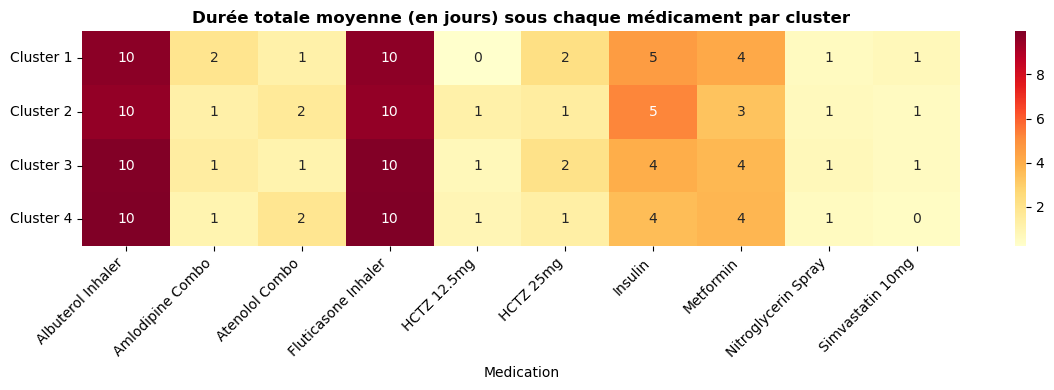

In [103]:
duree_med = timed_event_structure.copy()
duree_med['Medication'] = duree_med['Event'].map(dict(enumerate(noms_events)))
duree_par_patient = duree_med.groupby(['ID_PATIENT', 'Medication'])['Time'].count()
duree_pivot = duree_par_patient.unstack(fill_value=0)

# Moyenne par cluster
cluster_profiles = []
for c in sorted(set(clusters)):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    mean_duree = duree_pivot.loc[duree_pivot.index.isin(ids)].mean()
    cluster_profiles.append(mean_duree)

df_profiles = pd.DataFrame(cluster_profiles, index=[f"Cluster {c}" for c in sorted(set(clusters))])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df_profiles, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
ax.set_title("Durée totale moyenne (en jours) sous chaque médicament par cluster", fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

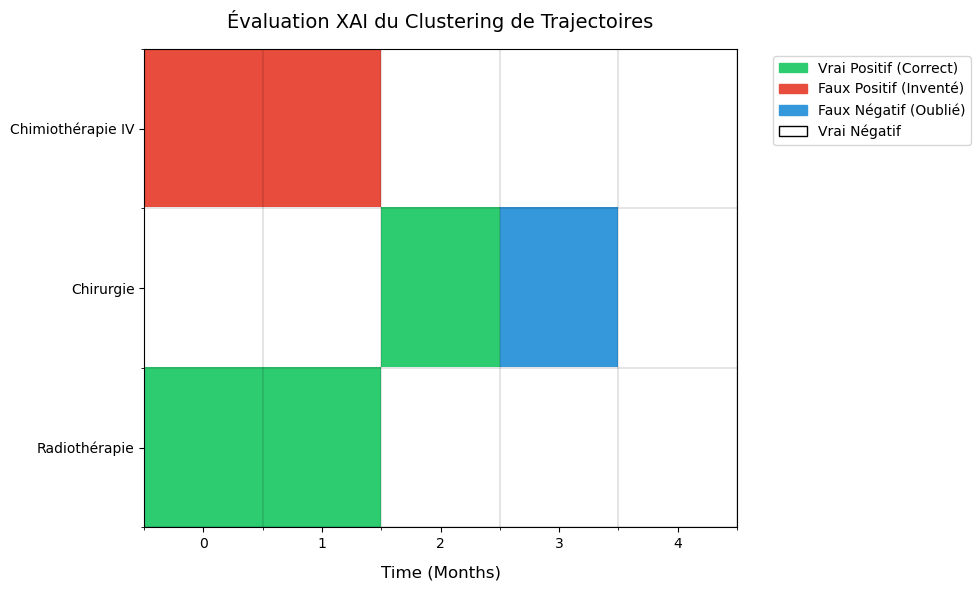

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def plot_xai_evaluation(mat_input, mat_reconstructed, events_labels):
    """
    Génère une carte d'évaluation XAI affichant TP, FP, FN et TN.
    """
    # 1. Binarisation de la prédiction (Seuil à 0.5 - modifiable selon ton modèle)
    mat_pred = (mat_reconstructed >= 0.5).astype(int)
    mat_true = mat_input.astype(int)
    
    # 2. Création de la matrice d'état (0=TN, 1=TP, 2=FP, 3=FN)
    state_matrix = np.zeros_like(mat_true)
    
    # Logique d'évaluation
    state_matrix[(mat_true == 1) & (mat_pred == 1)] = 1  # Vrai Positif (TP)
    state_matrix[(mat_true == 0) & (mat_pred == 1)] = 2  # Faux Positif (FP)
    state_matrix[(mat_true == 1) & (mat_pred == 0)] = 3  # Faux Négatif (FN)
    # Les Vrais Négatifs (TN) restent à 0
    
    # 3. Configuration des couleurs (Blanc, Vert, Rouge, Bleu)
    cmap = ListedColormap(['#FFFFFF', '#2ECC71', '#E74C3C', '#3498DB'])
    
    # 4. Affichage
    fig, ax = plt.subplots(figsize=(10, 6))
    cax = ax.imshow(state_matrix, cmap=cmap, vmin=0, vmax=3, aspect='auto')
    
    # Configuration des axes
    ax.set_yticks(np.arange(len(events_labels)))
    ax.set_yticklabels(events_labels)
    ax.set_xticks(np.arange(mat_true.shape[1]))
    ax.set_xlabel("Time (Months)", fontsize=12, labelpad=10)
    ax.set_title("Évaluation XAI du Clustering de Trajectoires", fontsize=14, pad=15)
    
    # Ajout d'une grille légère
    ax.set_xticks(np.arange(-.5, mat_true.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, mat_true.shape[0], 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1.5, alpha=0.1)
    
    # 5. Création d'une légende personnalisée
    legend_patches = [
        mpatches.Patch(color='#2ECC71', label='Vrai Positif (Correct)'),
        mpatches.Patch(color='#E74C3C', label='Faux Positif (Inventé)'),
        mpatches.Patch(color='#3498DB', label='Faux Négatif (Oublié)'),
        mpatches.Patch(facecolor='#FFFFFF', edgecolor='black', label='Vrai Négatif')
    ]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# --- TEST AVEC DONNÉES FICTIVES ---
# Vérité terrain
y_true = np.array([
    [0, 0, 0, 0, 0], 
    [0, 0, 1, 1, 0], # Événement réel aux mois 2 et 3
    [1, 1, 0, 0, 0]  # Événement réel aux mois 0 et 1
])

# Prédiction du modèle (après SWoTTeD)
y_pred = np.array([
    [0.9, 0.8, 0.0, 0.0, 0.0], # Le modèle invente ici (Faux Positifs)
    [0.0, 0.0, 0.9, 0.1, 0.0], # Le modèle trouve le mois 2 (TP) mais rate le mois 3 (FN)
    [0.8, 0.9, 0.0, 0.0, 0.0]  # Le modèle trouve tout (TP)
])

labels = ["Chimiothérapie IV", "Chirurgie", "Radiothérapie"]
plot_xai_evaluation(y_true, y_pred, labels)